# Indian Startup Funding Analysis

**Question:** Which sectors, cities and investors dominate Indian startup funding, and how has that changed over time?

This notebook cleans ~3,000 Indian startup funding records (2015–2020) and analyses funding concentration by sector, city, investor, deal type and year, using pandas for the analysis and SQLite to re-express and cross-check the key aggregations.

**Data:** [Indian Startup Funding — Kaggle](https://www.kaggle.com/datasets/sudalairajkumar/indian-startup-funding). Place `startup_funding.csv` in `data/raw/`.



### Contents
1. Setup and data loading
2. Data quality audit
3. Cleaning and standardisation
4. Key performance indicators
5. Sector analysis
6. City analysis
7. Investor analysis
8. Funding over time
9. Investment types and top startups
10. SQL analysis (including window functions)
11. Key findings, limitations and conclusion

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('/content/drive/My Drive')

Mounted at /content/drive


## 1. Setup and Data Loading

In [2]:
import os
import re
import sqlite3
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."
RAW_PATH = os.path.join(ROOT, "data", "raw", "startup_funding.csv")
CLEAN_PATH = os.path.join(ROOT, "data", "cleaned", "startup_funding_cleaned.csv")
FIG_DIR = os.path.join(ROOT, "reports", "figures")
TABLE_DIR = os.path.join(ROOT, "reports", "tables")
DB_PATH = os.path.join(ROOT, "data", "startup_funding.db")

for d in (FIG_DIR, TABLE_DIR, os.path.dirname(CLEAN_PATH)):
    os.makedirs(d, exist_ok=True)


def save_fig(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), bbox_inches="tight")
    plt.show()


def save_table(obj, name):
    obj.to_csv(os.path.join(TABLE_DIR, f"{name}.csv"))

In [3]:
df = pd.read_csv("startup_funding.csv", encoding='latin1')
print(df)


      Sr No Date dd/mm/yyyy                  Startup Name  \
0         1      09-01-2020                        BYJUS   
1         2      13-01-2020                        Shuttl   
2         3      09-01-2020                     Mamaearth   
3         4      02-01-2020  https://www.wealthbucket.in/   
4         5      02-01-2020                        Fashor   
...     ...             ...                           ...   
3039   3040      29-01-2015                    Printvenue   
3040   3041      29-01-2015                      Graphene   
3041   3042      30-01-2015                Mad Street Den   
3042   3043      30-01-2015                     Simplotel   
3043   3044      31-01-2015              couponmachine.in   

        Industry Vertical                            SubVertical  \
0                  E-Tech                             E-learning   
1          Transportation              App based shuttle service   
2              E-commerce  Retailer of baby and toddler product

## 2. Data Quality Audit



In [4]:
audit = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().sum() / len(df) * 100).round(2),
    "unique_values": df.nunique(),
})
audit.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct,unique_values
Remarks,2625,86.24,72
Amount in USD,960,31.54,471
SubVertical,936,30.75,1942
City Location,180,5.91,112
Industry Vertical,171,5.62,821
Investors Name,24,0.79,2412
InvestmentnType,4,0.13,55
Sr No,0,0.00,3044
Date dd/mm/yyyy,0,0.00,1035
Startup Name,0,0.00,2459


In [5]:
print(f"Fully duplicated rows: {df.duplicated().sum():,}")
print(f"Duplicated Sr No values: {df['Sr No'].duplicated().sum():,}")

naive = pd.to_datetime(df["Date dd/mm/yyyy"], format="%d/%m/%Y", errors="coerce")
print(f"\nDates lost to a strict %d/%m/%Y parse: {naive.isna().sum():,}")
print("Examples of the values that fail:")
print(df.loc[naive.isna(), "Date dd/mm/yyyy"].dropna().unique()[:8])

Fully duplicated rows: 0
Duplicated Sr No values: 0

Dates lost to a strict %d/%m/%Y parse: 3,044
Examples of the values that fail:
['09-01-2020' '13-01-2020' '02-01-2020' '10-01-2020' '12-12-2019'
 '06-12-2019' '03-12-2019' '13-12-2019']


## 3. Cleaning and Standardisation

### 3.1 Column names

In [6]:
data = df.copy()
data = data.rename(columns={
    "Sr No": "sr_no",
    "Date dd/mm/yyyy": "date",
    "Startup Name": "startup_name",
    "Industry Vertical": "industry",
    "SubVertical": "sub_vertical",
    "City  Location": "city",
    "Investors Name": "investors",
    "InvestmentnType": "investment_type",
    "Amount in USD": "funding_amount",
    "Remarks": "remarks",
})

data = data.drop_duplicates()

if data["remarks"].isna().mean() > 0.9:
    data = data.drop(columns=["remarks"])

print(data.columns.tolist())

['sr_no', 'date', 'startup_name', 'industry', 'sub_vertical', 'city', 'investors', 'investment_type', 'funding_amount', 'remarks']


### 3.2 Dates

Rather than assuming one fixed format, extract the day, month and year with a regular expression. This recovers rows that a strict `pd.to_datetime(format=...)` call would drop.

In [7]:
DATE_PATTERN = re.compile(r"(\d{1,2})\D*(\d{1,2})\D*(\d{2,4})")

def parse_date(value):
    """Parse a messy dd/mm/yyyy string into a Timestamp, or NaT.

    Handles '22/01//2015', '05/072018', '13/04.2015' and '01/07/015'.
    """
    match = DATE_PATTERN.search(str(value))
    if not match:
        return pd.NaT
    day, month, year = (int(g) for g in match.groups())
    if year < 100:
        year += 2000
    try:
        return pd.Timestamp(year=year, month=month, day=day)
    except ValueError:
        return pd.NaT

data["date"] = pd.to_datetime(data["date"], infer_datetime_format=True, errors='coerce')
data["year"] = data["date"].dt.year.astype("Int64")
data["month"] = data["date"].dt.month.astype("Int64")
data["month_name"] = data["date"].dt.month_name()

print(f"Dates parsed: {data['date'].notna().sum():,} of {len(data):,}")
print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")

Dates parsed: 1,292 of 3,044
Date range: 2015-01-05 to 2020-10-01


### 3.3 Funding amounts

Undisclosed rounds stay as `NaN`. Filling them with zero would drag every average down and imply a company raised nothing when in fact the amount simply was not reported.

In [8]:
UNDISCLOSED = {"", "-", "na", "n/a", "nan", "none", "null",
               "undisclosed", "unknown", "not disclosed"}


def parse_amount(value):
    """Convert a funding string to a float, or NaN when undisclosed."""
    text = str(value)
    for junk in ["\xa0", ",", "+", "$", "USD", "usd"]:   # \xa0 = non-breaking space
        text = text.replace(junk, "")
    text = text.strip()
    if text.lower() in UNDISCLOSED:
        return np.nan
    try:
        return float(text)
    except ValueError:
        return np.nan


data["funding_amount"] = data["funding_amount"].apply(parse_amount)
data["funding_million"] = data["funding_amount"] / 1_000_000

disclosed = data["funding_amount"].notna().sum()
print(f"Disclosed amounts: {disclosed:,} of {len(data):,} ({disclosed / len(data) * 100:.1f}%)")

Disclosed amounts: 2,066 of 3,044 (67.9%)


### 3.4 Text cleaning and label standardisation

The original columns are kept; standardised versions go into `*_clean` columns so the transformation stays auditable.

In [9]:
TEXT_COLUMNS = ["startup_name", "industry", "sub_vertical",
                "city", "investors", "investment_type"]

for col in TEXT_COLUMNS:
    data[col] = data[col].astype("string").str.strip()

for col in ["industry", "sub_vertical", "city", "investors", "investment_type"]:
    data[col] = data[col].fillna("Unknown")

data[TEXT_COLUMNS].isna().sum()

,0
startup_name,0
industry,0
sub_vertical,0
city,0
investors,0
investment_type,0


In [10]:
CITY_MAPPING = {
    "Bangalore": "Bengaluru", "Bangalore / Palo Alto": "Bengaluru",
    "Bangalore / SFO": "Bengaluru", "Bangalore / USA": "Bengaluru",
    "Gurgaon": "Gurugram", "New Delhi": "Delhi", "Bombay": "Mumbai",
}

INDUSTRY_MAPPING = {
    "eCommerce": "E-Commerce", "ECommerce": "E-Commerce", "Ecommerce": "E-Commerce",
    "E-commerce": "E-Commerce", "e-commerce": "E-Commerce", "ecommerce": "E-Commerce",
    "Online Marketplace": "E-Commerce",
    "FinTech": "Finance", "Fin-Tech": "Finance", "Fintech": "Finance",
    "Financial Services": "Finance",
    "Ed-Tech": "Education", "EdTech": "Education", "Edtech": "Education",
    "Health and Wellness": "Healthcare", "HealthCare": "Healthcare",
    "consumer Internet": "Consumer Internet",
}

INVESTMENT_MAPPING = {
    "Seed\nFunding": "Seed Funding", "Seed/ Funding": "Seed Funding",
    "Seed/Funding": "Seed Funding", "Seed funding": "Seed Funding",
    "seed funding": "Seed Funding", "Seed Round": "Seed Funding",
    "Seed/Angel Funding": "Seed / Angel Funding",
    "Seed /Angel Funding": "Seed / Angel Funding",
    "Seed / Angle Funding": "Seed / Angel Funding",
    "Angel / Seed Funding": "Seed / Angel Funding",
    "Angel/Seed Funding": "Seed / Angel Funding",
    "Private equity": "Private Equity", "PrivateEquity": "Private Equity",
    "Private Equity Round": "Private Equity",
    "Debt funding": "Debt Funding", "Debt-Funding": "Debt Funding",
}

STARTUP_MAPPING = {
    "Ola Cabs": "Ola", "Olacabs": "Ola", "OlaCabs": "Ola",
    "Flipkart.com": "Flipkart", "Snapdeal.com": "Snapdeal",
    "Oyo Rooms": "OYO", "OyoRooms": "OYO", "Oyorooms": "OYO",
    "OYO Rooms": "OYO", "Oyo": "OYO", "Paytm Mall": "Paytm",
}

data["city_clean"] = data["city"].replace(CITY_MAPPING)
data["industry_clean"] = data["industry"].replace(INDUSTRY_MAPPING)
data["investment_type_clean"] = (
    data["investment_type"].str.replace(r"\s+", " ", regex=True).str.strip()
    .replace(INVESTMENT_MAPPING)
)
data["startup_clean"] = data["startup_name"].replace(STARTUP_MAPPING)

print("Distinct cities:", data["city"].nunique(), "->", data["city_clean"].nunique())
print("Distinct industries:", data["industry"].nunique(), "->", data["industry_clean"].nunique())
print("Distinct startups:", data["startup_name"].nunique(), "->", data["startup_clean"].nunique())

Distinct cities: 113 -> 107
Distinct industries: 822 -> 809
Distinct startups: 2459 -> 2452


### 3.5 Business-level deduplication

The same round occasionally appears twice with a different `Sr No`. Deduplicating on the business key (startup, date, amount, investors) rather than the whole row catches these.

In [11]:
before = len(data)
data = data.drop_duplicates(
    subset=["startup_clean", "date", "funding_amount", "investors"]
).reset_index(drop=True)
print(f"Removed {before - len(data):,} duplicate deals -> {len(data):,} rows")

data.to_csv(CLEAN_PATH, index=False)
print(f"Saved -> {CLEAN_PATH}")
data.head()

Removed 2 duplicate deals -> 3,042 rows
Saved -> ./data/cleaned/startup_funding_cleaned.csv


,sr_no,date,startup_name,industry,sub_vertical,city,investors,investment_type,funding_amount,remarks,year,month,month_name,funding_million,city_clean,industry_clean,investment_type_clean,startup_clean
0,1,2020-09-01,BYJUS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"200,000,000.00",NaN,2020,9,September,200.00,Bengaluru,E-Tech,Private Equity,BYJUS
1,2,NaT,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"8,048,394.00",NaN,<NA>,<NA>,NaN,8.05,Gurugram,Transportation,Series C,Shuttl
2,3,2020-09-01,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"18,358,860.00",NaN,2020,9,September,18.36,Bengaluru,E-Commerce,Series B,Mamaearth
3,4,2020-02-01,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"3,000,000.00",NaN,2020,2,February,3.00,Delhi,Finance,Pre-series A,https://www.wealthbucket.in/
4,5,2020-02-01,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"1,800,000.00",NaN,2020,2,February,1.80,Mumbai,Fashion and Apparel,Seed Funding,Fashor


## 4. Key Performance Indicators

In [12]:
data["funding_amount"] = data["funding_amount"].apply(parse_amount) # Re-apply cleaning to ensure numeric
kpis = {
    "Total funding records": len(data),
    "Unique startups": data["startup_clean"].nunique(),
    "Records with disclosed funding": int(data["funding_amount"].notna().sum()),
    "Funding data coverage (%)": round(data["funding_amount"].notna().mean() * 100, 2),
    "Total disclosed funding (USD)": data["funding_amount"].sum(),
    "Mean deal size (USD)": data["funding_amount"].mean(),
    "Median deal size (USD)": data["funding_amount"].median(),
}

for key, value in kpis.items():
    print(f"{key:<35} {value:>20,.2f}")

save_table(pd.Series(kpis, name="value"), "kpis")

Total funding records                           3,042.00
Unique startups                                 2,452.00
Records with disclosed funding                  2,064.00
Funding data coverage (%)                          67.85
Total disclosed funding (USD)          38,071,779,864.22
Mean deal size (USD)                       18,445,629.78
Median deal size (USD)                      1,750,000.00


## 5. Sector Analysis

In [13]:
sector_funding = data.groupby("industry_clean")["funding_amount"].sum().sort_values(ascending=False)
sector_deals = data.groupby("industry_clean").size().sort_values(ascending=False)
sector_average = data.groupby("industry_clean")["funding_amount"].mean().sort_values(ascending=False)
sector_share = (sector_funding / sector_funding.sum() * 100).round(2)

sector_summary = pd.DataFrame({
    "total_funding": sector_funding,
    "deals": sector_deals,
    "average_deal": sector_average,
    "share_pct": sector_share,
}).sort_values("total_funding", ascending=False)

save_table(sector_summary, "sector_summary")
sector_summary.head(10)

,total_funding,deals,average_deal,share_pct
industry_clean,,,,
E-Commerce,"8,960,778,692.54",300,"43,498,925.69",23.54
Consumer Internet,"6,253,084,245.00",941,"10,616,441.84",16.42
Transportation,"3,916,632,394.00",4,"979,158,098.50",10.29
Finance,"3,336,349,265.00",78,"45,703,414.59",8.76
Technology,"2,229,707,930.00",478,"7,192,606.23",5.86
Unknown,"1,231,611,368.00",170,"9,473,933.60",3.23
Healthcare,"871,418,000.00",75,"17,784,040.82",2.29
E-Commerce & M-Commerce platform,"680,000,000.00",1,"680,000,000.00",1.79
B2B,"587,000,000.00",2,"293,500,000.00",1.54


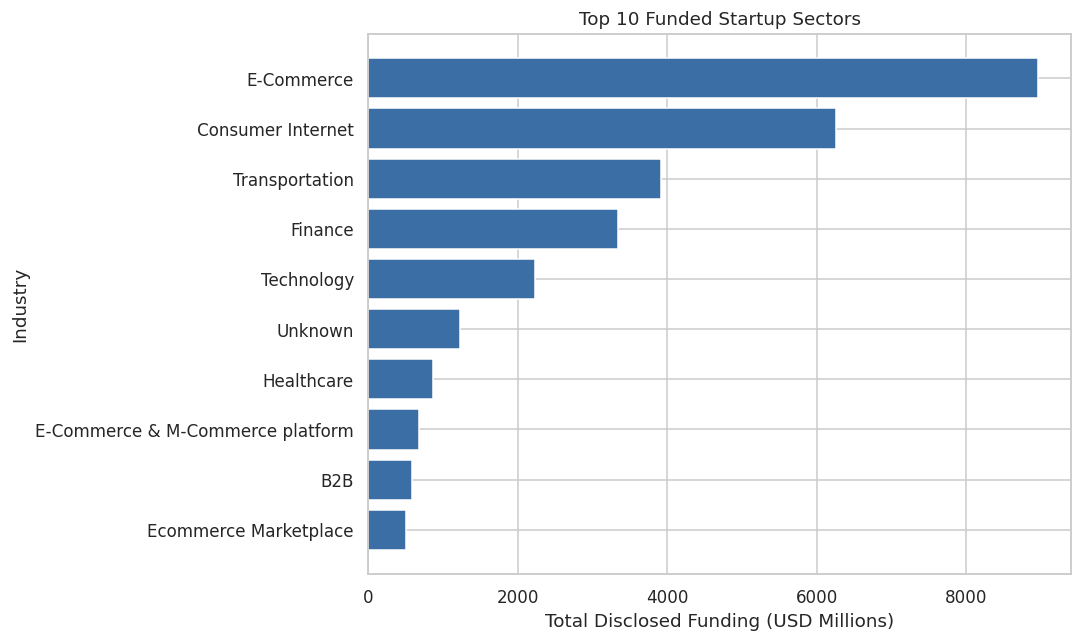

In [14]:
top_sectors = sector_funding.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_sectors.index.astype(str), top_sectors.values / 1_000_000, color="#3b6ea5")
plt.title("Top 10 Funded Startup Sectors")
plt.xlabel("Total Disclosed Funding (USD Millions)")
plt.ylabel("Industry")
save_fig("top_sectors_funding")

In [15]:
comparison = pd.DataFrame({
    "rank_by_funding": sector_funding.rank(ascending=False).astype(int),
    "rank_by_deals": sector_deals.rank(ascending=False).astype(int),
}).loc[sector_funding.head(10).index]
comparison["rank_gap"] = comparison["rank_by_deals"] - comparison["rank_by_funding"]
comparison

,rank_by_funding,rank_by_deals,rank_gap
industry_clean,,,
E-Commerce,1,3,2
Consumer Internet,2,1,-1
Transportation,3,17,14
Finance,4,5,1
Technology,5,2,-3
Unknown,6,4,-2
Healthcare,7,6,-1
E-Commerce & M-Commerce platform,8,439,431
B2B,9,49,40


## 6. City Analysis

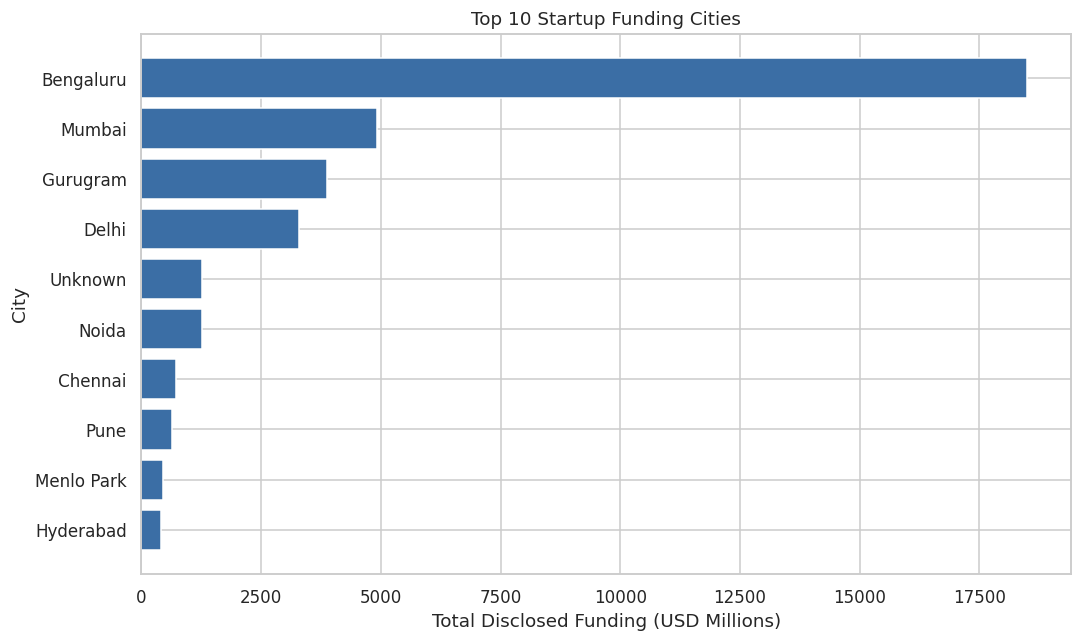

Bengaluru, Mumbai, Gurugram account for 71.7% of all disclosed funding.


In [16]:
city_funding = data.groupby("city_clean")["funding_amount"].sum().sort_values(ascending=False)
city_deals = data.groupby("city_clean").size().sort_values(ascending=False)

city_summary = pd.DataFrame({"total_funding": city_funding, "deals": city_deals}) \
    .sort_values("total_funding", ascending=False)
save_table(city_summary, "city_summary")

top_cities = city_funding.head(10).sort_values()
plt.figure(figsize=(10, 6))
plt.barh(top_cities.index.astype(str), top_cities.values / 1_000_000, color="#3b6ea5")
plt.title("Top 10 Startup Funding Cities")
plt.xlabel("Total Disclosed Funding (USD Millions)")
plt.ylabel("City")
save_fig("top_cities_funding")

top3 = city_funding.head(3)
print(f"{', '.join(top3.index)} account for "
      f"{top3.sum() / city_funding.sum() * 100:.1f}% of all disclosed funding.")

## 7. Investor Analysis



In [17]:
def explode_investors(frame):
    """Return one row per (deal, investor) pair, dropping undisclosed entries."""
    exploded = frame.assign(investor=frame["investors"].str.split(",")).explode("investor")
    exploded["investor"] = exploded["investor"].str.strip()
    drop = {"", "unknown", "undisclosed", "undisclosed investor",
            "undisclosed investors", "nan"}
    mask = exploded["investor"].notna() & ~exploded["investor"].str.lower().isin(drop)
    return exploded[mask].reset_index(drop=True)


investors = explode_investors(data) # Changed df to data
print(f"{len(data):,} deals -> {len(investors):,} investor-deal pairs")
print(f"Distinct investors: {investors['investor'].nunique():,}")
print(f"Average investors per deal: {len(investors) / len(data):.2f}")

3,042 deals -> 5,624 investor-deal pairs
Distinct investors: 3,285
Average investors per deal: 1.85


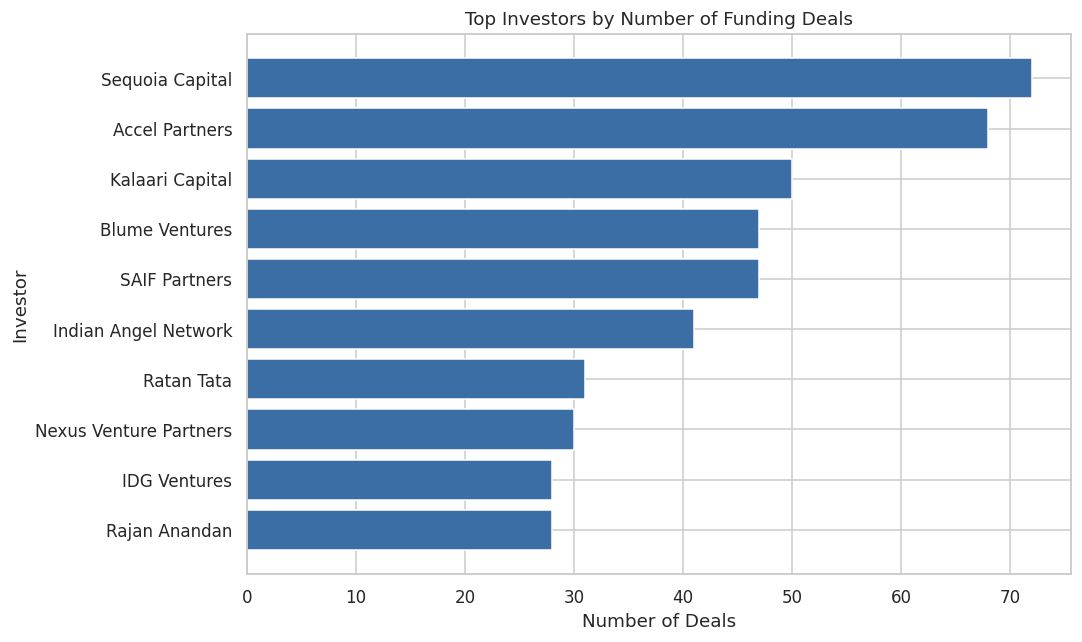

,count
investor,
Sequoia Capital,72
Accel Partners,68
Kalaari Capital,50
SAIF Partners,47
Blume Ventures,47
Indian Angel Network,41
Ratan Tata,31
Nexus Venture Partners,30
IDG Ventures,28


In [18]:
top_investors = investors["investor"].value_counts().head(20)
investor_funding = investors.groupby("investor")["funding_amount"].sum().sort_values(ascending=False)

save_table(top_investors, "top_investors_by_deals")
save_table(investor_funding.head(20), "top_investors_by_funding")

top_10 = top_investors.head(10).sort_values()
plt.figure(figsize=(10, 6))
plt.barh(top_10.index.astype(str), top_10.values, color="#3b6ea5")
plt.title("Top Investors by Number of Funding Deals")
plt.xlabel("Number of Deals")
plt.ylabel("Investor")
save_fig("top_investors_deals")

top_investors.head(10)

## 8. Funding Over Time

In [19]:
dated = data.dropna(subset=["year"]).copy()
dated["year"] = dated["year"].astype(int)

yearly = pd.DataFrame({
    "total_funding": dated.groupby("year")["funding_amount"].sum(),
    "deals": dated.groupby("year").size(),
    "average_deal": dated.groupby("year")["funding_amount"].mean(),
    "median_deal": dated.groupby("year")["funding_amount"].median(),
}).sort_index()

yearly["yoy_growth_pct"] = (yearly["total_funding"].pct_change() * 100).round(1)
save_table(yearly, "yearly_summary")
yearly

,total_funding,deals,average_deal,median_deal,yoy_growth_pct
year,,,,,
2015,"3,587,210,368.00",389,"13,335,354.53","1,200,000.00",NaN
2016,"1,527,965,000.00",399,"6,447,109.70","1,000,000.00",-57.40
2017,"4,702,502,000.00",294,"24,115,394.87","2,300,000.00",207.80
2018,"2,301,147,824.00",136,"20,009,981.08","4,300,000.00",-51.10
2019,"2,854,097,895.22",69,"43,243,907.50","7,660,410.00",24.00
2020,"373,158,860.00",5,"74,631,772.00","18,358,860.00",-86.90


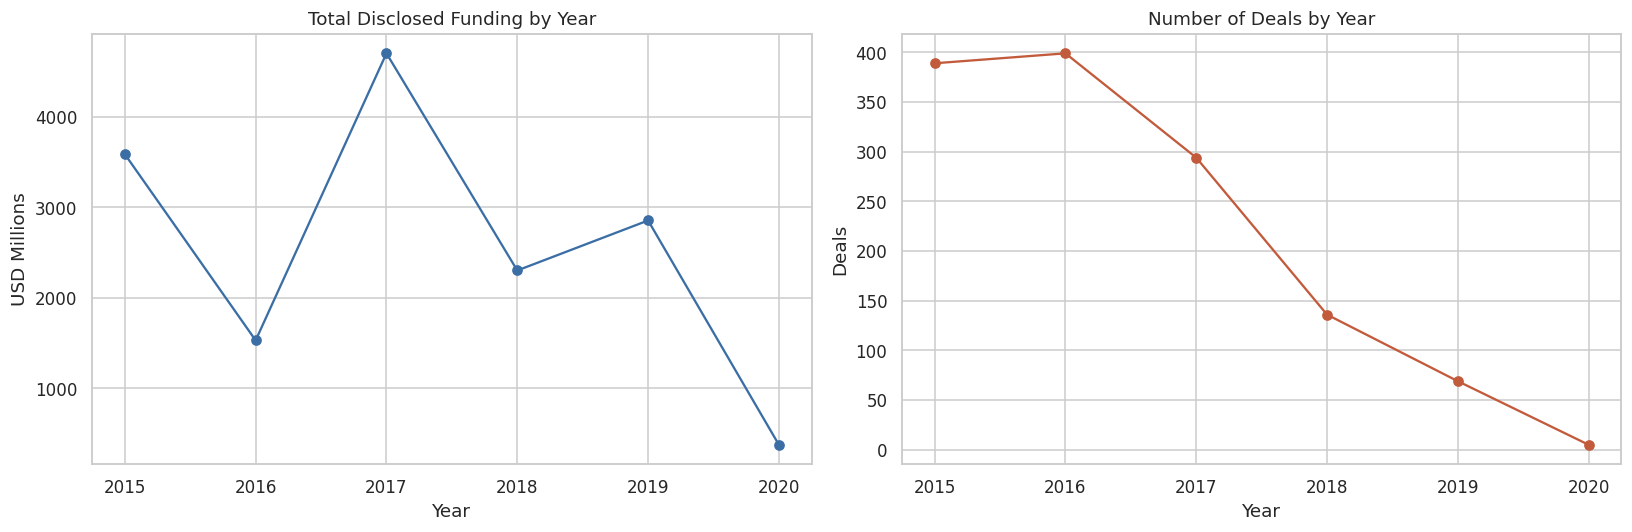

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(yearly.index, yearly["total_funding"] / 1_000_000, marker="o", color="#3b6ea5")
axes[0].set_title("Total Disclosed Funding by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("USD Millions")
axes[0].set_xticks(yearly.index)

axes[1].plot(yearly.index, yearly["deals"], marker="o", color="#c25a3c")
axes[1].set_title("Number of Deals by Year")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Deals")
axes[1].set_xticks(yearly.index)

save_fig("yearly_trends")

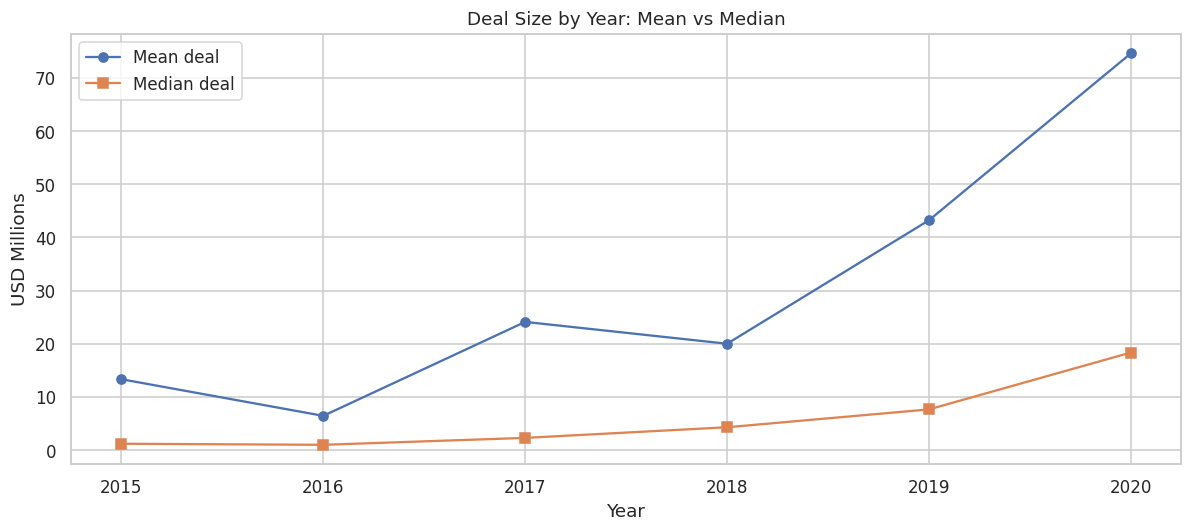

Peak funding year: 2017
Peak deal-count year: 2016


In [21]:
plt.figure(figsize=(11, 5))
plt.plot(yearly.index, yearly["average_deal"] / 1_000_000, marker="o", label="Mean deal")
plt.plot(yearly.index, yearly["median_deal"] / 1_000_000, marker="s", label="Median deal")
plt.title("Deal Size by Year: Mean vs Median")
plt.xlabel("Year")
plt.ylabel("USD Millions")
plt.xticks(yearly.index)
plt.legend()
save_fig("deal_size_by_year")

print("Peak funding year:", int(yearly['total_funding'].idxmax()))
print("Peak deal-count year:", int(yearly['deals'].idxmax()))

## 9. Investment Types and Top Startups

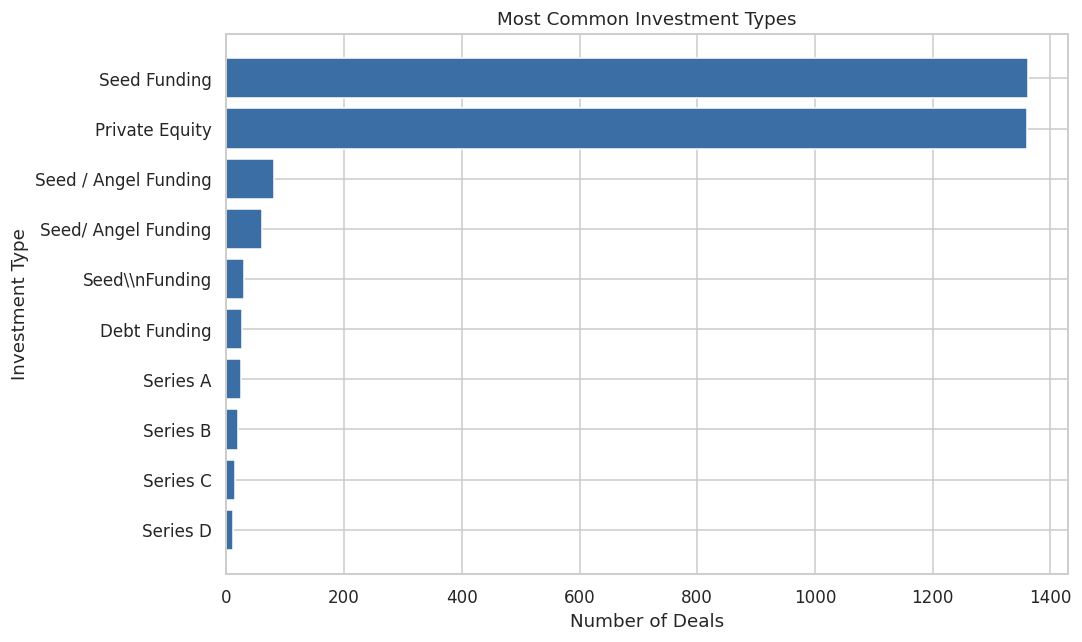

In [22]:
type_deals = data.groupby("investment_type_clean").size().sort_values(ascending=False)
type_funding = data.groupby("investment_type_clean")["funding_amount"].sum().sort_values(ascending=False)

save_table(pd.DataFrame({"deals": type_deals, "total_funding": type_funding}), "investment_types")

top_types = type_deals.head(10).sort_values()
plt.figure(figsize=(10, 6))
plt.barh(top_types.index.astype(str), top_types.values, color="#3b6ea5")
plt.title("Most Common Investment Types")
plt.xlabel("Number of Deals")
plt.ylabel("Investment Type")
save_fig("investment_types")

In [23]:
top_startups = (
    data.groupby("startup_clean")
    .agg(deals=("startup_clean", "count"), total_funding=("funding_amount", "sum"))
    .sort_values("total_funding", ascending=False)
)
save_table(top_startups.head(20), "top_startups")
top_startups.head(15)

,deals,total_funding
startup_clean,,
Flipkart,6,"4,759,700,000.00"
Rapido Bike Taxi,1,"3,900,000,000.00"
Paytm,7,"3,148,950,000.00"
Ola,13,"2,054,200,000.00"
OYO,9,"997,000,000.00"
Udaan,4,"870,000,000.00"
Snapdeal,2,"700,000,000.00"
True North,1,"600,000,000.00"
BigBasket,4,"507,000,000.00"


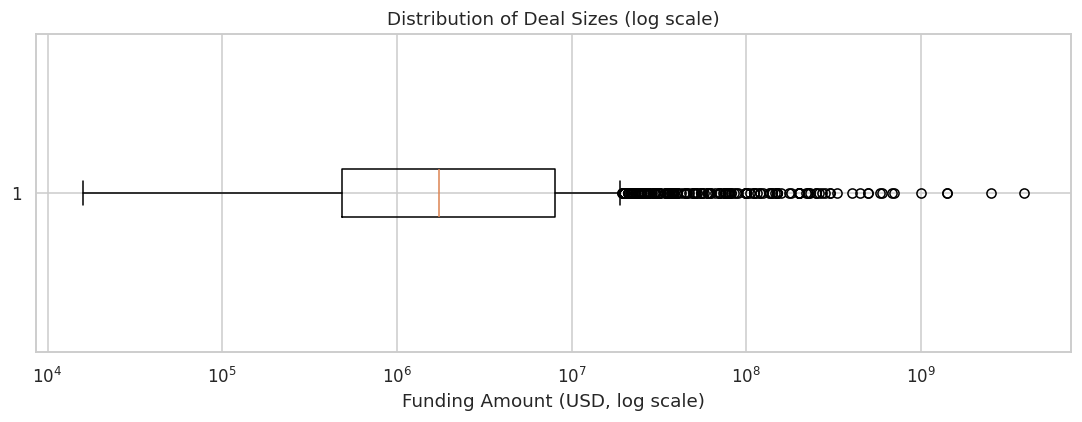

,funding_amount
count,"2,064.00"
mean,"18,445,629.78"
std,"121,401,555.43"
min,"16,000.00"
25%,"483,250.00"
50%,"1,750,000.00"
75%,"8,000,000.00"
max,"3,900,000,000.00"


In [24]:
plt.figure(figsize=(10, 4))
plt.boxplot(data["funding_amount"].dropna(), vert=False)
plt.xscale("log")
plt.title("Distribution of Deal Sizes (log scale)")
plt.xlabel("Funding Amount (USD, log scale)")
save_fig("funding_distribution")

data["funding_amount"].describe()

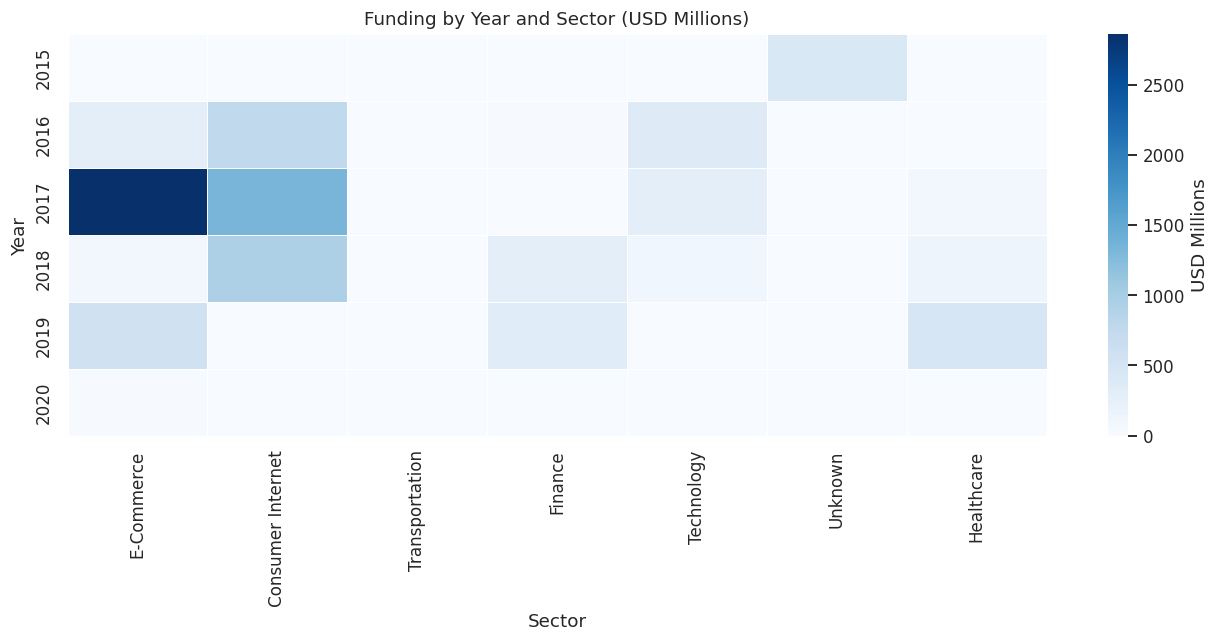

,dominant_sector
year,
2015,Ecommerce Marketplace
2016,Consumer Internet
2017,E-Commerce
2018,Consumer Internet
2019,B2B
2020,E-Tech


In [25]:
year_sector = pd.pivot_table(
    dated, values="funding_amount", index="year",
    columns="industry_clean", aggfunc="sum",
)
save_table(year_sector, "year_sector_pivot")

top_cols = sector_funding.head(8).index
top_cols = top_cols[top_cols.isin(year_sector.columns)]

plt.figure(figsize=(12, 6))
sns.heatmap((year_sector[top_cols] / 1_000_000).fillna(0), cmap="Blues",
            linewidths=0.4, cbar_kws={"label": "USD Millions"})
plt.title("Funding by Year and Sector (USD Millions)")
plt.xlabel("Sector")
plt.ylabel("Year")
save_fig("year_sector_heatmap")

year_sector.idxmax(axis=1).rename("dominant_sector")

## 10. SQL Analysis

The same aggregations are re-expressed in SQL against a SQLite database. Running both paths over identical data doubles as a cross-check: if the pandas and SQL answers disagree, one of them has a bug.

In [26]:
conn = sqlite3.connect(DB_PATH)
data.to_sql("startup_funding", conn, if_exists="replace", index=False)
pd.read_sql("SELECT * FROM startup_funding LIMIT 5", conn)

,sr_no,date,startup_name,industry,sub_vertical,city,investors,investment_type,funding_amount,remarks,year,month,month_name,funding_million,city_clean,industry_clean,investment_type_clean,startup_clean
0,1,2020-09-01 00:00:00,BYJUS,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"200,000,000.00",None,"2,020.00",9.00,September,200.00,Bengaluru,E-Tech,Private Equity,BYJUS
1,2,None,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"8,048,394.00",None,NaN,NaN,None,8.05,Gurugram,Transportation,Series C,Shuttl
2,3,2020-09-01 00:00:00,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"18,358,860.00",None,"2,020.00",9.00,September,18.36,Bengaluru,E-Commerce,Series B,Mamaearth
3,4,2020-02-01 00:00:00,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"3,000,000.00",None,"2,020.00",2.00,February,3.00,Delhi,Finance,Pre-series A,https://www.wealthbucket.in/
4,5,2020-02-01 00:00:00,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"1,800,000.00",None,"2,020.00",2.00,February,1.80,Mumbai,Fashion and Apparel,Seed Funding,Fashor


In [27]:
query = """
SELECT industry_clean AS industry,
       COUNT(*) AS number_of_deals,
       SUM(funding_amount) AS total_funding,
       ROUND(AVG(funding_amount), 2) AS average_funding
FROM startup_funding
WHERE funding_amount IS NOT NULL
GROUP BY industry_clean
ORDER BY total_funding DESC
LIMIT 10;
"""
sql_sectors = pd.read_sql(query, conn)
sql_sectors

,industry,number_of_deals,total_funding,average_funding
0,E-Commerce,206,"8,960,778,692.54","43,498,925.69"
1,Consumer Internet,589,"6,253,084,245.00","10,616,441.84"
2,Transportation,4,"3,916,632,394.00","979,158,098.50"
3,Finance,73,"3,336,349,265.00","45,703,414.59"
4,Technology,310,"2,229,707,930.00","7,192,606.23"
5,Unknown,130,"1,231,611,368.00","9,473,933.60"
6,Healthcare,49,"871,418,000.00","17,784,040.82"
7,E-Commerce & M-Commerce platform,1,"680,000,000.00","680,000,000.00"
8,B2B,2,"587,000,000.00","293,500,000.00"
9,Ecommerce Marketplace,1,"500,000,000.00","500,000,000.00"


In [28]:
pandas_top = sector_funding.head(10).round(2).values
sql_top = sql_sectors["total_funding"].round(2).values
print("SQL and pandas agree on top 10 sectors:", np.allclose(pandas_top, sql_top))

SQL and pandas agree on top 10 sectors: True


In [29]:
query = """
SELECT city_clean AS city,
       COUNT(*) AS number_of_deals,
       SUM(funding_amount) AS total_funding
FROM startup_funding
WHERE funding_amount IS NOT NULL
GROUP BY city_clean
ORDER BY total_funding DESC
LIMIT 10;
"""
pd.read_sql(query, conn)

,city,number_of_deals,total_funding
0,Bengaluru,587,"18,495,808,863.00"
1,Mumbai,401,"4,921,185,015.00"
2,Gurugram,241,"3,871,228,657.54"
3,Delhi,265,"3,291,471,515.00"
4,Unknown,134,"1,271,663,868.00"
5,Noida,55,"1,262,864,000.00"
6,Chennai,75,"718,767,000.00"
7,Pune,71,"633,082,000.00"
8,Menlo Park,1,"450,000,000.00"
9,Hyderabad,72,"401,076,230.00"


query = """
SELECT city_clean AS city,
       COUNT(*) AS number_of_deals,
       SUM(funding_amount) AS total_funding
FROM startup_funding
WHERE funding_amount IS NOT NULL
GROUP BY city_clean
ORDER BY total_funding DESC
LIMIT 10;
"""
pd.read_sql(query, conn)
### Window function: top 3 sectors within each year

`RANK() OVER (PARTITION BY year ...)` ranks sectors inside each year, which a plain `GROUP BY` cannot do in one pass.

In [30]:
query = """
SELECT year, industry, total_funding, sector_rank
FROM (
    SELECT year,
           industry_clean AS industry,
           SUM(funding_amount) AS total_funding,
           RANK() OVER (
               PARTITION BY year
               ORDER BY SUM(funding_amount) DESC
           ) AS sector_rank
    FROM startup_funding
    WHERE funding_amount IS NOT NULL AND year IS NOT NULL
    GROUP BY year, industry_clean
)
WHERE sector_rank <= 3
ORDER BY year, sector_rank;
"""
pd.read_sql(query, conn)

,year,industry,total_funding,sector_rank
0,2015,Ecommerce Marketplace,"500,000,000.00",1
1,2015,Unknown,"428,073,368.00",2
2,2015,Cab Aggregator,"400,000,000.00",3
3,2016,Consumer Internet,"762,512,000.00",1
4,2016,Technology,"362,773,000.00",2
5,2016,E-Commerce,"286,000,000.00",3
6,2017,E-Commerce,"2,861,867,000.00",1
7,2017,Consumer Internet,"1,338,063,000.00",2
8,2017,Technology,"297,409,000.00",3
9,2018,Consumer Internet,"948,741,000.00",1


### Window function: year-on-year growth

`LAG()` pulls the previous year's total onto the current row so growth can be computed without a self-join.

In [31]:
query = """
WITH yearly AS (
    SELECT year, SUM(funding_amount) AS total_funding
    FROM startup_funding
    WHERE funding_amount IS NOT NULL AND year IS NOT NULL
    GROUP BY year
)
SELECT year,
       total_funding,
       LAG(total_funding) OVER (ORDER BY year) AS previous_year,
       ROUND(
           (total_funding - LAG(total_funding) OVER (ORDER BY year))
           * 100.0 / LAG(total_funding) OVER (ORDER BY year), 2
       ) AS yoy_growth_pct
FROM yearly
ORDER BY year;
"""
pd.read_sql(query, conn)

,year,total_funding,previous_year,yoy_growth_pct
0,2015,"3,587,210,368.00",NaN,NaN
1,2016,"1,527,965,000.00","3,587,210,368.00",-57.41
2,2017,"4,702,502,000.00","1,527,965,000.00",207.76
3,2018,"2,301,147,824.00","4,702,502,000.00",-51.07
4,2019,"2,854,097,895.22","2,301,147,824.00",24.03
5,2020,"373,158,860.00","2,854,097,895.22",-86.93


In [32]:
query = """
SELECT startup_clean AS startup,
       COUNT(*) AS number_of_deals,
       SUM(funding_amount) AS total_funding
FROM startup_funding
WHERE funding_amount IS NOT NULL
GROUP BY startup_clean
ORDER BY total_funding DESC
LIMIT 15;
"""
pd.read_sql(query, conn)

,startup,number_of_deals,total_funding
0,Flipkart,6,"4,759,700,000.00"
1,Rapido Bike Taxi,1,"3,900,000,000.00"
2,Paytm,5,"3,148,950,000.00"
3,Ola,12,"2,054,200,000.00"
4,OYO,9,"997,000,000.00"
5,Udaan,4,"870,000,000.00"
6,Snapdeal,2,"700,000,000.00"
7,True North,1,"600,000,000.00"
8,BigBasket,4,"507,000,000.00"
9,GOQii,1,"450,000,000.00"


In [33]:
conn.close()
print("Database connection closed.")

Database connection closed.


conn.close()
print("Database connection closed.")
## 11. Key Findings

The cell below generates the headline numbers directly from the cleaned data, so the written conclusions can never drift out of sync with the analysis.

In [34]:
findings = [
    f"The dataset holds {len(df):,} funding records covering "
    f"{data['startup_clean'].nunique():,} unique startups, but only "
    f"{data['funding_amount'].notna().mean() * 100:.1f}% disclose an amount. "
    f"All totals are disclosed funding, not market size.",

    f"The median deal is ${data['funding_amount'].median():,.0f} against a mean of "
    f"${data['funding_amount'].mean():,.0f} - a handful of mega-rounds pull the average "
    f"well above the typical deal.",

    f"{sector_funding.index[0]} leads on capital raised with "
    f"${sector_funding.iloc[0] / 1_000_000:,.0f}M ({sector_share.iloc[0]:.1f}% of all "
    f"disclosed funding), while {sector_deals.index[0]} records the most deals "
    f"({sector_deals.iloc[0]:,}).",

    f"Funding is geographically concentrated: {', '.join(city_funding.head(3).index)} "
    f"together account for {city_funding.head(3).sum() / city_funding.sum() * 100:.1f}% "
    f"of disclosed funding.",

    f"{top_investors.index[0]} is the most active investor with {top_investors.iloc[0]:,} "
    f"deals, ahead of {top_investors.index[1]} ({top_investors.iloc[1]:,}).",

    f"Capital peaked in {int(yearly['total_funding'].idxmax())} "
    f"(${yearly['total_funding'].max() / 1_000_000:,.0f}M) while deal count peaked in "
    f"{int(yearly['deals'].idxmax())} ({yearly['deals'].max():,} deals) - fewer but "
    f"larger rounds in the later years.",

    f"{type_deals.index[0]} is the most common deal structure ({type_deals.iloc[0]:,} deals), "
    f"consistent with an early-stage-heavy market.",

    f"{top_startups.index[0]} raised the most overall "
    f"(${top_startups['total_funding'].iloc[0] / 1_000_000:,.0f}M across "
    f"{int(top_startups['deals'].iloc[0])} disclosed rounds).",
]

findings_md = "# Key Findings\n\n" + "\n".join(f"- {f}" for f in findings) + "\n"

with open(os.path.join(ROOT, "reports", "key_findings.md"), "w", encoding="utf-8") as handle:
    handle.write(findings_md)

print(findings_md)

# Key Findings

- The dataset holds 3,044 funding records covering 2,452 unique startups, but only 67.9% disclose an amount. All totals are disclosed funding, not market size.
- The median deal is $1,750,000 against a mean of $18,445,630 - a handful of mega-rounds pull the average well above the typical deal.
- E-Commerce leads on capital raised with $8,961M (23.5% of all disclosed funding), while Consumer Internet records the most deals (941).
- Funding is geographically concentrated: Bengaluru, Mumbai, Gurugram together account for 71.7% of disclosed funding.
- Sequoia Capital is the most active investor with 72 deals, ahead of Accel Partners (68).
- Capital peaked in 2017 ($4,703M) while deal count peaked in 2016 (399 deals) - fewer but larger rounds in the later years.
- Seed Funding is the most common deal structure (1,362 deals), consistent with an early-stage-heavy market.
- Flipkart raised the most overall ($4,760M across 6 disclosed rounds).




## Limitations

- A large share of deals do not disclose an amount, so all totals represent **disclosed funding**, not true market size. Sectors with better disclosure habits will look larger than they are.
- When several investors share a single record, the full round is attributed to each of them. Investor totals therefore measure participation, not cheque size, and must not be summed.
- Industry, city and investment-type labels come from the source dataset and inherit its classification choices. The standardisation mappings above are judgement calls and are deliberately kept explicit and auditable.
- Coverage ends in 2020 and the dataset is not guaranteed to include every Indian funding transaction, so absolute totals understate the market.
- Deals with unparseable dates are excluded from time-series analysis only, not from sector or city totals.

## Conclusion

Indian startup funding in this dataset is concentrated on three axes at once: a small number of sectors, three metropolitan areas, and a short list of repeat investors. The mean–median gap and the divergence between the peak funding year and the peak deal-count year both point the same way — the market's headline totals are driven by a handful of very large rounds rather than by broad-based activity.

The practical implication is that any benchmark built on averages here will mislead. Median deal size by sector and year is the more defensible reference point, and the disclosure rate should be reported alongside any total.

Methodologically, the main risk in this dataset is silent data loss: strict date parsing and naive investor counting both fail quietly rather than raising errors. Quantifying what each cleaning step recovered, and cross-checking the pandas aggregations against SQL, were the two safeguards used here.